---
d.1 gerar uma imagem Binária (Preto e Branco) da Lena-Color, conforme o limiar indicado (55%);
---

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

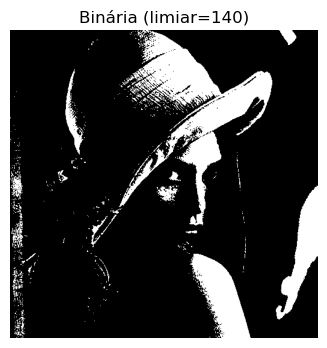

In [2]:
img = cv2.imread(r"C:\Users\ericd\PDI_novo\PDI II\pdi2_ime\trabalho_2\lena-Color.png", cv2.IMREAD_GRAYSCALE)

percentual = 55
limiar = round((percentual / 100) * 255)      # 140

_,binaria = cv2.threshold(img, limiar, 255, cv2.THRESH_BINARY)
cv2.imwrite("saida_binaria_55pct.png", binaria)

plt.figure(figsize=(12, 4))
plt.subplot(1, 1, 1)
plt.imshow(binaria, cmap="gray", vmin=0, vmax=255)
plt.title(f"Binária (limiar={limiar})")
plt.axis("off")

---
d.2 gerar uma imagem Pancromática (Níveis de Cinza) da Lena-Color;
---

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

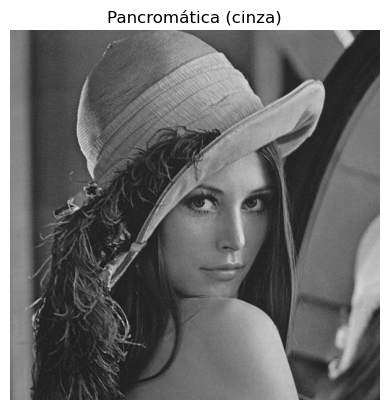

In [3]:
import cv2

img = cv2.imread(r"C:\Users\ericd\PDI_novo\PDI II\pdi2_ime\trabalho_2\lena-Color.png")                
cinza = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)   

cv2.imwrite("saida_pancromatica.png", cinza)
plt.subplot(1, 1, 1)
plt.imshow(cinza, cmap="gray", vmin=0, vmax=255)
plt.title("Pancromática (cinza)")
plt.axis("off")

---
d.3 aplicar o método comum e o específico às três imagens da Lena;
---

---
1º: Usando método comum


=== RGB ===
Tempo para montar codec: 0.027730 s
Tempo para codificar    : 0.141191 s
Tempo para decodificar  : 0.756919 s
Tempo total : 0.926159 s
Tamanho original        : 786432 bytes
Tamanho comprimido      : 736865 bytes
Taxa de compressão      : 1.0673 (original/comprimido)


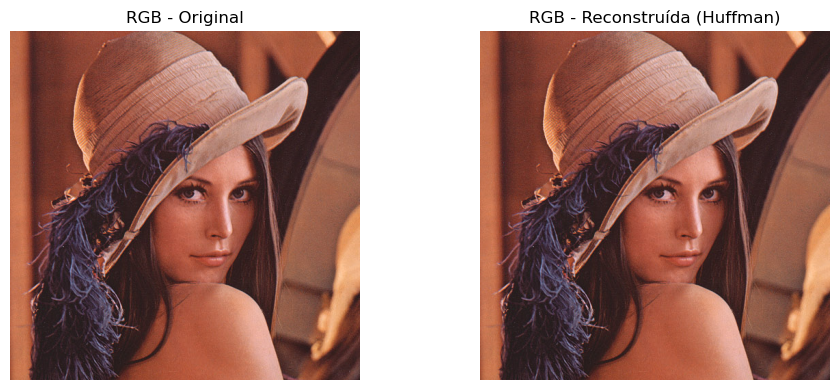

In [38]:
import time  
import numpy as np  
import cv2  
import matplotlib.pyplot as plt  
from dahuffman import HuffmanCodec  

CAMINHO_RGB = r"C:\Users\ericd\PDI_novo\PDI II\pdi2_ime\trabalho_2\lena-Color.png"

img_bgr = cv2.imread(CAMINHO_RGB, cv2.IMREAD_COLOR)

if img_bgr is None:
    raise FileNotFoundError(f"Não consegui abrir a imagem RGB em: {CAMINHO_RGB}")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

data = img_rgb.tobytes()

t0 = time.perf_counter()
codec = HuffmanCodec.from_data(data)
t1 = time.perf_counter()

t2 = time.perf_counter()
comp = codec.encode(data)  
t3 = time.perf_counter()

t4 = time.perf_counter()
dec = codec.decode(comp)  
t5 = time.perf_counter()

dec_bytes = bytes(dec)
img_rec = np.frombuffer(dec_bytes, dtype=np.uint8).reshape(img_rgb.shape)

original_bytes = len(data)
comprimido_bytes = len(comp)
taxa = original_bytes / comprimido_bytes if comprimido_bytes > 0 else float("inf")

print("=== RGB ===")
print(f"Tempo para montar codec: {t1 - t0:.6f} s")
print(f"Tempo para codificar    : {t3 - t2:.6f} s")
print(f"Tempo para decodificar  : {t5 - t4:.6f} s")
print(f"Tempo total : {t5 - t0:.6f} s")
print(f"Tamanho original        : {original_bytes} bytes")
print(f"Tamanho comprimido      : {comprimido_bytes} bytes")
print(f"Taxa de compressão      : {taxa:.4f} (original/comprimido)")

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("RGB - Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_rec)
plt.title("RGB - Reconstruída (Huffman)")
plt.axis("off")

plt.tight_layout()
plt.show()

=== Pancromática (Gray) ===
Tempo para montar codec: 0.009852 s
Tempo para codificar    : 0.045976 s
Tempo para decodificar  : 0.288415 s
Tempo total : 0.344664 s
Tamanho original        : 262144 bytes
Tamanho comprimido      : 238441 bytes
Taxa de compressão      : 1.0994 (original/comprimido)


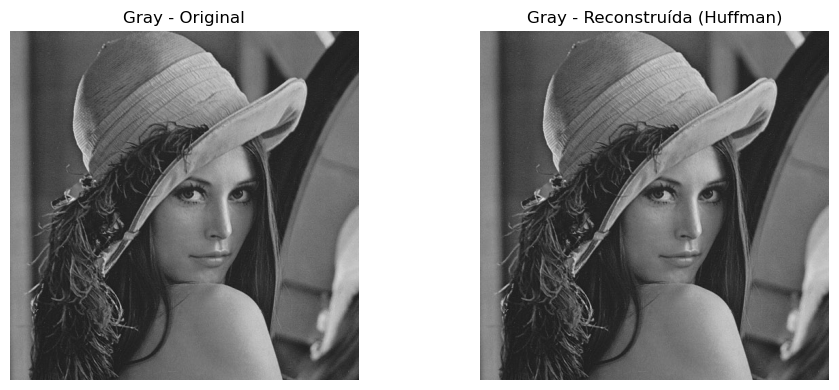

In [39]:
import time
import numpy as np
import cv2
import matplotlib.pyplot as plt
from dahuffman import HuffmanCodec

CAMINHO_GRAY = r"C:\Users\ericd\PDI_novo\PDI II\pdi2_ime\trabalho_2\saida_pancromatica.png"

img_gray = cv2.imread(CAMINHO_GRAY, cv2.IMREAD_GRAYSCALE)

if img_gray is None:
    raise FileNotFoundError(f"Não consegui abrir a imagem pancromática em: {CAMINHO_GRAY}")

data = img_gray.tobytes()

t0 = time.perf_counter()
codec = HuffmanCodec.from_data(data)
t1 = time.perf_counter()

t2 = time.perf_counter()
comp = codec.encode(data)
t3 = time.perf_counter()

t4 = time.perf_counter()
dec = codec.decode(comp)
t5 = time.perf_counter()

dec_bytes = bytes(dec)
img_rec = np.frombuffer(dec_bytes, dtype=np.uint8).reshape(img_gray.shape)

original_bytes = len(data)
comprimido_bytes = len(comp)
taxa = original_bytes / comprimido_bytes if comprimido_bytes > 0 else float("inf")

print("=== Pancromática (Gray) ===")
print(f"Tempo para montar codec: {t1 - t0:.6f} s")
print(f"Tempo para codificar    : {t3 - t2:.6f} s")
print(f"Tempo para decodificar  : {t5 - t4:.6f} s")
print(f"Tempo total : {t5 - t0:.6f} s")
print(f"Tamanho original        : {original_bytes} bytes")
print(f"Tamanho comprimido      : {comprimido_bytes} bytes")
print(f"Taxa de compressão      : {taxa:.4f} (original/comprimido)")

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap="gray", vmin=0, vmax=255)
plt.title("Gray - Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_rec, cmap="gray", vmin=0, vmax=255)
plt.title("Gray - Reconstruída (Huffman)")
plt.axis("off")

plt.tight_layout()
plt.show()

=== Binária (0/255) ===
Tempo para montar codec: 0.007829 s
Tempo para codificar    : 0.024995 s
Tempo para decodificar  : 0.069265 s
Tempo total : 0.102652 s
Tamanho original        : 262144 bytes
Tamanho comprimido      : 37815 bytes
Taxa de compressão      : 6.9323 (original/comprimido)


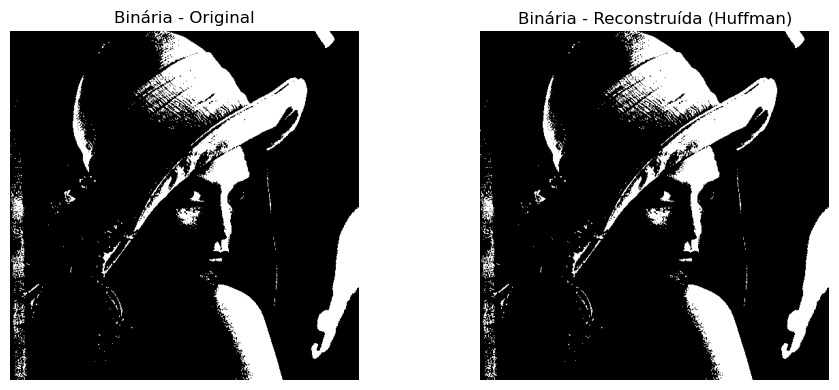

In [40]:
import time
import numpy as np
import cv2
import matplotlib.pyplot as plt
from dahuffman import HuffmanCodec

CAMINHO_BIN = r"C:\Users\ericd\PDI_novo\PDI II\pdi2_ime\trabalho_2\saida_binaria_55pct.png"

img_bin = cv2.imread(CAMINHO_BIN, cv2.IMREAD_GRAYSCALE)

if img_bin is None:
    raise FileNotFoundError(f"Não consegui abrir a imagem binária em: {CAMINHO_BIN}")

img_bin = np.where(img_bin >= 128, 255, 0).astype(np.uint8)

data = img_bin.tobytes()

t0 = time.perf_counter()
codec = HuffmanCodec.from_data(data)
t1 = time.perf_counter()

t2 = time.perf_counter()
comp = codec.encode(data)
t3 = time.perf_counter()

t4 = time.perf_counter()
dec = codec.decode(comp)
t5 = time.perf_counter()

dec_bytes = bytes(dec)
img_rec = np.frombuffer(dec_bytes, dtype=np.uint8).reshape(img_bin.shape)

original_bytes = len(data)
comprimido_bytes = len(comp)
taxa = original_bytes / comprimido_bytes if comprimido_bytes > 0 else float("inf")

print("=== Binária (0/255) ===")
print(f"Tempo para montar codec: {t1 - t0:.6f} s")
print(f"Tempo para codificar    : {t3 - t2:.6f} s")
print(f"Tempo para decodificar  : {t5 - t4:.6f} s")
print(f"Tempo total : {t5 - t0:.6f} s")
print(f"Tamanho original        : {original_bytes} bytes")
print(f"Tamanho comprimido      : {comprimido_bytes} bytes")
print(f"Taxa de compressão      : {taxa:.4f} (original/comprimido)")

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(img_bin, cmap="gray", vmin=0, vmax=255)
plt.title("Binária - Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_rec, cmap="gray", vmin=0, vmax=255)
plt.title("Binária - Reconstruída (Huffman)")
plt.axis("off")

plt.tight_layout()
plt.show()

---
2º: usando método específico (codificação baseada em símbolos)

c:\Users\ericd\PDI_novo\PDI II\pdi2_ime\.pixi\envs\default\Lib\site-packages\sklearn\cluster\_kmeans.py:1962: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 2560 or by setting the environment variable OMP_NUM_THREADS=8
  warnings.warn(


=== RGB | Tokens/Símbolos (sem Huffman) ===
Tempo treino dicionário : 2.622841 s
Tempo tokenização       : 0.014246 s
Tempo total             : 2.637632 s
Tamanho original        : 786432 bytes
Tamanho codebook        : 12288 bytes
Tamanho tokens          : 32768 bytes
Total (codebook+tokens) : 45056 bytes
Taxa (orig / total)     : 17.4545


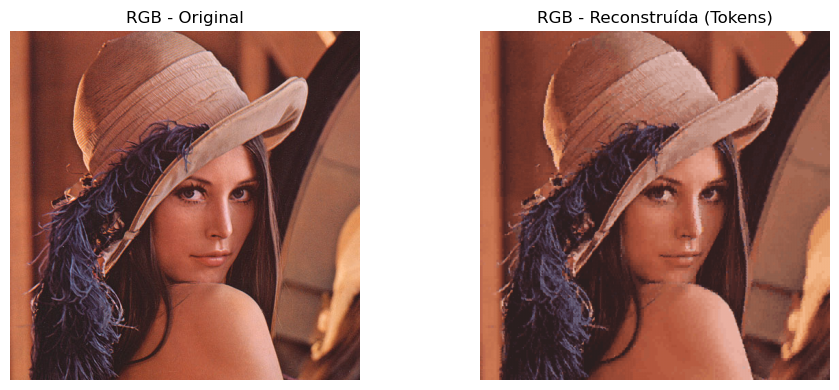

In [41]:
import time
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.cluster import MiniBatchKMeans


CAMINHO_RGB = r"C:\Users\ericd\PDI_novo\PDI II\pdi2_ime\trabalho_2\lena-Color.png"
PATCH = 4                 
K = 256                   
AMOSTRAS_TREINO = 50000   


def pad_to_multiple(img, patch):
    h, w = img.shape[:2]
    pad_h = (-h) % patch
    pad_w = (-w) % patch
    if pad_h == 0 and pad_w == 0:
        return img, (0, 0)
    img_pad = cv2.copyMakeBorder(img, 0, pad_h, 0, pad_w, cv2.BORDER_REFLECT)
    return img_pad, (pad_h, pad_w)

def img_to_patches_rgb(img_rgb, patch):
    h, w, c = img_rgb.shape
    img_ = img_rgb.reshape(h // patch, patch, w // patch, patch, c)
    img_ = img_.transpose(0, 2, 1, 3, 4)
    patches = img_.reshape(-1, patch * patch * c)
    return patches, (h, w, c)

def patches_to_img_rgb(tokens, codebook, shape_hw_c, patch):
    h, w, c = shape_hw_c
    nH = h // patch
    nW = w // patch
    vecs = codebook[tokens]
    blocks = vecs.reshape(nH, nW, patch, patch, c)
    blocks = blocks.transpose(0, 2, 1, 3, 4)
    img_rec = blocks.reshape(h, w, c)
    return img_rec.astype(np.uint8)


img_bgr = cv2.imread(CAMINHO_RGB, cv2.IMREAD_COLOR)
if img_bgr is None:
    raise FileNotFoundError(f"Não consegui abrir: {CAMINHO_RGB}")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)


img_pad, (pad_h, pad_w) = pad_to_multiple(img_rgb, PATCH)
patches, shape_hw_c = img_to_patches_rgb(img_pad, PATCH)


rng = np.random.default_rng(0)
idx = rng.choice(len(patches), size=min(AMOSTRAS_TREINO, len(patches)), replace=False)
train = patches[idx].astype(np.float32)

t0 = time.perf_counter()
kmeans = MiniBatchKMeans(n_clusters=K, random_state=0, batch_size=2048, n_init=3)
kmeans.fit(train)
t1 = time.perf_counter()

codebook = np.clip(kmeans.cluster_centers_, 0, 255).astype(np.uint8)


t2 = time.perf_counter()
tokens = kmeans.predict(patches.astype(np.float32)).astype(np.uint16 if K <= 65535 else np.uint32)
t3 = time.perf_counter()


img_rec_pad = patches_to_img_rgb(tokens.astype(np.int32), codebook, shape_hw_c, PATCH)

h0, w0 = img_rgb.shape[:2]
img_rec = img_rec_pad[:h0, :w0, :]


original_bytes = img_rgb.nbytes
codebook_bytes = codebook.nbytes
tokens_bytes = tokens.nbytes
total_model_bytes = codebook_bytes + tokens_bytes  

print("=== RGB | Tokens/Símbolos (sem Huffman) ===")
print(f"Tempo treino dicionário : {t1 - t0:.6f} s")
print(f"Tempo tokenização       : {t3 - t2:.6f} s")
print(f"Tempo total             : {t3 - t0:.6f} s")
print(f"Tamanho original        : {original_bytes} bytes")
print(f"Tamanho codebook        : {codebook_bytes} bytes")
print(f"Tamanho tokens          : {tokens_bytes} bytes")
print(f"Total (codebook+tokens) : {total_model_bytes} bytes")
print(f"Taxa (orig / total)     : {original_bytes / total_model_bytes:.4f}")


plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("RGB - Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_rec)
plt.title("RGB - Reconstruída (Tokens)")
plt.axis("off")

plt.tight_layout()
plt.show()

=== Gray | Tokens/Símbolos (sem Huffman) ===
Tempo treino dicionário : 2.600611 s
Tempo tokenização       : 0.003055 s
Tempo total : 2.603779 s
Tamanho original        : 262144 bytes
Tamanho codebook        : 4096 bytes
Tamanho tokens          : 32768 bytes
Total (codebook+tokens) : 36864 bytes
Taxa (orig / total)     : 7.1111


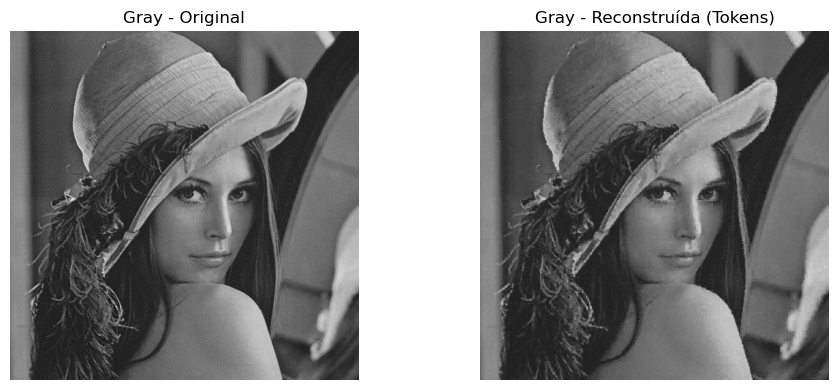

In [42]:
import time
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.cluster import MiniBatchKMeans


CAMINHO_GRAY = r"C:\Users\ericd\PDI_novo\PDI II\pdi2_ime\trabalho_2\saida_pancromatica.png"
PATCH = 4
K = 256
AMOSTRAS_TREINO = 70000


def img_to_patches_gray(img_gray, patch):
    h, w = img_gray.shape
    img_ = img_gray.reshape(h // patch, patch, w // patch, patch)
    img_ = img_.transpose(0, 2, 1, 3)
    patches = img_.reshape(-1, patch * patch)
    return patches, (h, w)

def patches_to_img_gray(tokens, codebook, shape_hw, patch):
    h, w = shape_hw
    nH = h // patch
    nW = w // patch
    vecs = codebook[tokens]
    blocks = vecs.reshape(nH, nW, patch, patch)
    blocks = blocks.transpose(0, 2, 1, 3)
    img_rec = blocks.reshape(h, w)
    return img_rec.astype(np.uint8)

img_gray = cv2.imread(CAMINHO_GRAY, cv2.IMREAD_GRAYSCALE)
if img_gray is None:
    raise FileNotFoundError(f"Não consegui abrir: {CAMINHO_GRAY}")

img_pad, (pad_h, pad_w) = pad_to_multiple(img_gray, PATCH)
patches, shape_hw = img_to_patches_gray(img_pad, PATCH)

rng = np.random.default_rng(0)
idx = rng.choice(len(patches), size=min(AMOSTRAS_TREINO, len(patches)), replace=False)
train = patches[idx].astype(np.float32)

t0 = time.perf_counter()
kmeans = MiniBatchKMeans(n_clusters=K, random_state=0, batch_size=4096, n_init=3)
kmeans.fit(train)
t1 = time.perf_counter()

codebook = np.clip(kmeans.cluster_centers_, 0, 255).astype(np.uint8)


t2 = time.perf_counter()
tokens = kmeans.predict(patches.astype(np.float32)).astype(np.uint16 if K <= 65535 else np.uint32)
t3 = time.perf_counter()

img_rec_pad = patches_to_img_gray(tokens.astype(np.int32), codebook, shape_hw, PATCH)

h0, w0 = img_gray.shape
img_rec = img_rec_pad[:h0, :w0]

original_bytes = img_gray.nbytes
codebook_bytes = codebook.nbytes
tokens_bytes = tokens.nbytes
total_model_bytes = codebook_bytes + tokens_bytes

print("=== Gray | Tokens/Símbolos (sem Huffman) ===")
print(f"Tempo treino dicionário : {t1 - t0:.6f} s")
print(f"Tempo tokenização       : {t3 - t2:.6f} s")
print(f"Tempo total : {t3 - t0:.6f} s")
print(f"Tamanho original        : {original_bytes} bytes")
print(f"Tamanho codebook        : {codebook_bytes} bytes")
print(f"Tamanho tokens          : {tokens_bytes} bytes")
print(f"Total (codebook+tokens) : {total_model_bytes} bytes")
print(f"Taxa (orig / total)     : {original_bytes / total_model_bytes:.4f}")

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap="gray", vmin=0, vmax=255)
plt.title("Gray - Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_rec, cmap="gray", vmin=0, vmax=255)
plt.title("Gray - Reconstruída (Tokens)")
plt.axis("off")

plt.tight_layout()
plt.show()

=== Binária | Tokens/Símbolos (sem Huffman) ===
Tempo treino dicionário : 0.340010 s
Tempo tokenização       : 0.001981 s
Tempo total             : 0.342312 s
Tamanho original        : 262144 bytes
Tamanho codebook        : 2048 bytes
Tamanho tokens          : 8192 bytes
Total (codebook+tokens) : 10240 bytes
Taxa (orig / total)     : 25.6000


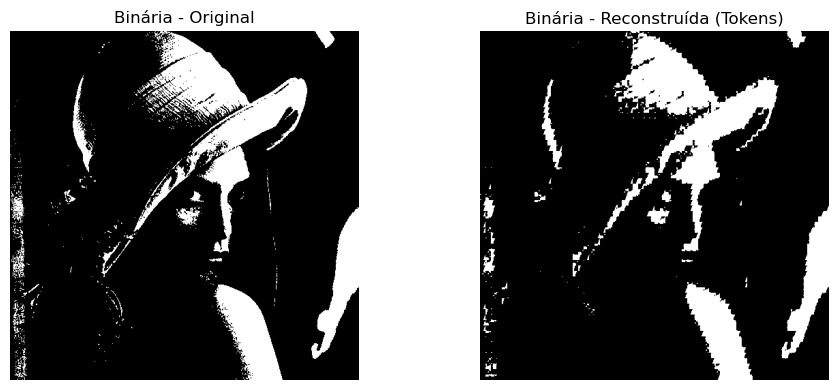

In [43]:
import time
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.cluster import MiniBatchKMeans

CAMINHO_BIN = r"C:\Users\ericd\PDI_novo\PDI II\pdi2_ime\trabalho_2\saida_binaria_55pct.png"
PATCH = 8       
K = 32           
AMOSTRAS_TREINO = 70000

def img_to_patches_gray(img_gray, patch):
    h, w = img_gray.shape
    img_ = img_gray.reshape(h // patch, patch, w // patch, patch)
    img_ = img_.transpose(0, 2, 1, 3)
    patches = img_.reshape(-1, patch * patch)
    return patches, (h, w)

def patches_to_img_gray(tokens, codebook, shape_hw, patch):
    h, w = shape_hw
    nH = h // patch
    nW = w // patch
    vecs = codebook[tokens]
    blocks = vecs.reshape(nH, nW, patch, patch)
    blocks = blocks.transpose(0, 2, 1, 3)
    img_rec = blocks.reshape(h, w)
    return img_rec.astype(np.uint8)

img_bin = cv2.imread(CAMINHO_BIN, cv2.IMREAD_GRAYSCALE)
if img_bin is None:
    raise FileNotFoundError(f"Não consegui abrir: {CAMINHO_BIN}")

img_bin = np.where(img_bin >= 128, 255, 0).astype(np.uint8)

img_pad, (pad_h, pad_w) = pad_to_multiple(img_bin, PATCH)
patches, shape_hw = img_to_patches_gray(img_pad, PATCH)

rng = np.random.default_rng(0)
idx = rng.choice(len(patches), size=min(AMOSTRAS_TREINO, len(patches)), replace=False)
train = patches[idx].astype(np.float32)

t0 = time.perf_counter()
kmeans = MiniBatchKMeans(n_clusters=K, random_state=0, batch_size=4096, n_init=5)
kmeans.fit(train)
t1 = time.perf_counter()

codebook = np.where(kmeans.cluster_centers_ >= 128, 255, 0).astype(np.uint8)

t2 = time.perf_counter()
tokens = kmeans.predict(patches.astype(np.float32)).astype(np.uint16 if K <= 65535 else np.uint32)
t3 = time.perf_counter()

img_rec_pad = patches_to_img_gray(tokens.astype(np.int32), codebook, shape_hw, PATCH)

h0, w0 = img_bin.shape
img_rec = img_rec_pad[:h0, :w0]


original_bytes = img_bin.nbytes
codebook_bytes = codebook.nbytes
tokens_bytes = tokens.nbytes
total_model_bytes = codebook_bytes + tokens_bytes

print("=== Binária | Tokens/Símbolos (sem Huffman) ===")
print(f"Tempo treino dicionário : {t1 - t0:.6f} s")
print(f"Tempo tokenização       : {t3 - t2:.6f} s")
print(f"Tempo total             : {t3 - t0:.6f} s")
print(f"Tamanho original        : {original_bytes} bytes")
print(f"Tamanho codebook        : {codebook_bytes} bytes")
print(f"Tamanho tokens          : {tokens_bytes} bytes")
print(f"Total (codebook+tokens) : {total_model_bytes} bytes")
print(f"Taxa (orig / total)     : {original_bytes / total_model_bytes:.4f}")

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(img_bin, cmap="gray", vmin=0, vmax=255)
plt.title("Binária - Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_rec, cmap="gray", vmin=0, vmax=255)
plt.title("Binária - Reconstruída (Tokens)")
plt.axis("off")

plt.tight_layout()
plt.show()

---
d.4 aplicar o método o método comum e o específico à imagem especificada ao grupo.
---

=== Area 23 ===
Tempo para montar codec: 0.589675 s
Tempo para codificar    : 3.035138 s
Tempo para decodificar  : 16.939952 s
Tempo total  : 20.565927 s
Tamanho original        : 14535114 bytes
Tamanho comprimido      : 12786440 bytes
Taxa de compressão      : 1.1368 (original/comprimido)


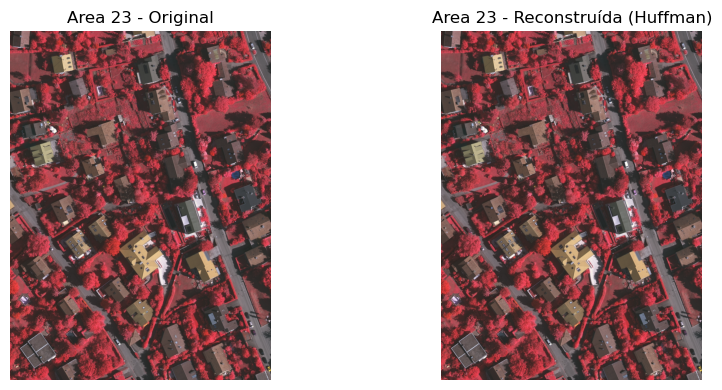

In [44]:
import time  
import numpy as np  
import cv2  
import matplotlib.pyplot as plt  
from dahuffman import HuffmanCodec  

CAMINHO_A23 = r"C:\Users\ericd\PDI_novo\PDI II\pdi2_ime\trabalho_2\top_mosaic_09cm_area23.tif"

img_bgr = cv2.imread(CAMINHO_A23, cv2.IMREAD_COLOR)

if img_bgr is None:
    raise FileNotFoundError(f"Não consegui abrir a imagem RGB em: {CAMINHO_A23}")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

data = img_rgb.tobytes()

t0 = time.perf_counter()
codec = HuffmanCodec.from_data(data)
t1 = time.perf_counter()

t2 = time.perf_counter()
comp = codec.encode(data)  
t3 = time.perf_counter()

t4 = time.perf_counter()
dec = codec.decode(comp)  
t5 = time.perf_counter()

dec_bytes = bytes(dec)
img_rec = np.frombuffer(dec_bytes, dtype=np.uint8).reshape(img_rgb.shape)

original_bytes = len(data)
comprimido_bytes = len(comp)
taxa = original_bytes / comprimido_bytes if comprimido_bytes > 0 else float("inf")

print("=== Area 23 ===")
print(f"Tempo para montar codec: {t1 - t0:.6f} s")
print(f"Tempo para codificar    : {t3 - t2:.6f} s")
print(f"Tempo para decodificar  : {t5 - t4:.6f} s")
print(f"Tempo total  : {t5 - t0:.6f} s")
print(f"Tamanho original        : {original_bytes} bytes")
print(f"Tamanho comprimido      : {comprimido_bytes} bytes")
print(f"Taxa de compressão      : {taxa:.4f} (original/comprimido)")

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Area 23 - Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_rec)
plt.title("Area 23 - Reconstruída (Huffman)")
plt.axis("off")

plt.tight_layout()
plt.show()

c:\Users\ericd\PDI_novo\PDI II\pdi2_ime\.pixi\envs\default\Lib\site-packages\sklearn\cluster\_kmeans.py:1962: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 2560 or by setting the environment variable OMP_NUM_THREADS=8
  warnings.warn(


=== Area 23 | Tokens/Símbolos ===
Tempo treino dicionário : 3.499956 s
Tempo tokenização       : 0.011948 s
Tempo total             : 3.512307 s
Tamanho original        : 786432 bytes
Tamanho codebook        : 12288 bytes
Tamanho tokens          : 32768 bytes
Total (codebook+tokens) : 45056 bytes
Taxa (orig / total)     : 17.4545


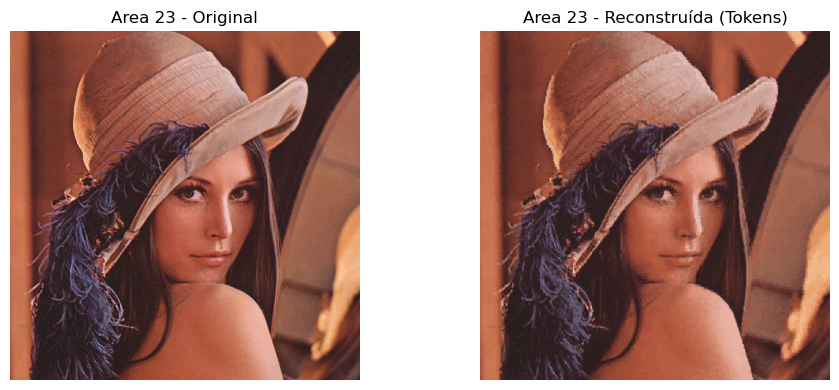

In [45]:
import time
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.cluster import MiniBatchKMeans


CAMINHO_TIF = r"C:\Users\ericd\PDI_novo\PDI II\pdi2_ime\trabalho_2\top_mosaic_09cm_area23.tif"
PATCH = 4                 
K = 256                   
AMOSTRAS_TREINO = 50000   


def pad_to_multiple(img, patch):
    h, w = img.shape[:2]
    pad_h = (-h) % patch
    pad_w = (-w) % patch
    if pad_h == 0 and pad_w == 0:
        return img, (0, 0)
    img_pad = cv2.copyMakeBorder(img, 0, pad_h, 0, pad_w, cv2.BORDER_REFLECT)
    return img_pad, (pad_h, pad_w)

def img_to_patches_rgb(img_rgb, patch):
    h, w, c = img_rgb.shape
    img_ = img_rgb.reshape(h // patch, patch, w // patch, patch, c)
    img_ = img_.transpose(0, 2, 1, 3, 4)
    patches = img_.reshape(-1, patch * patch * c)
    return patches, (h, w, c)

def patches_to_img_rgb(tokens, codebook, shape_hw_c, patch):
    h, w, c = shape_hw_c
    nH = h // patch
    nW = w // patch
    vecs = codebook[tokens]
    blocks = vecs.reshape(nH, nW, patch, patch, c)
    blocks = blocks.transpose(0, 2, 1, 3, 4)
    img_rec = blocks.reshape(h, w, c)
    return img_rec.astype(np.uint8)


img_bgr = cv2.imread(CAMINHO_RGB, cv2.IMREAD_COLOR)
if img_bgr is None:
    raise FileNotFoundError(f"Não consegui abrir: {CAMINHO_RGB}")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)


img_pad, (pad_h, pad_w) = pad_to_multiple(img_rgb, PATCH)
patches, shape_hw_c = img_to_patches_rgb(img_pad, PATCH)


rng = np.random.default_rng(0)
idx = rng.choice(len(patches), size=min(AMOSTRAS_TREINO, len(patches)), replace=False)
train = patches[idx].astype(np.float32)

t0 = time.perf_counter()
kmeans = MiniBatchKMeans(n_clusters=K, random_state=0, batch_size=2048, n_init=3)
kmeans.fit(train)
t1 = time.perf_counter()

codebook = np.clip(kmeans.cluster_centers_, 0, 255).astype(np.uint8)


t2 = time.perf_counter()
tokens = kmeans.predict(patches.astype(np.float32)).astype(np.uint16 if K <= 65535 else np.uint32)
t3 = time.perf_counter()


img_rec_pad = patches_to_img_rgb(tokens.astype(np.int32), codebook, shape_hw_c, PATCH)

h0, w0 = img_rgb.shape[:2]
img_rec = img_rec_pad[:h0, :w0, :]


original_bytes = img_rgb.nbytes
codebook_bytes = codebook.nbytes
tokens_bytes = tokens.nbytes
total_model_bytes = codebook_bytes + tokens_bytes  

print("=== Area 23 | Tokens/Símbolos ===")
print(f"Tempo treino dicionário : {t1 - t0:.6f} s")
print(f"Tempo tokenização       : {t3 - t2:.6f} s")
print(f"Tempo total             : {t3 - t0:.6f} s")
print(f"Tamanho original        : {original_bytes} bytes")
print(f"Tamanho codebook        : {codebook_bytes} bytes")
print(f"Tamanho tokens          : {tokens_bytes} bytes")
print(f"Total (codebook+tokens) : {total_model_bytes} bytes")
print(f"Taxa (orig / total)     : {original_bytes / total_model_bytes:.4f}")


plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Area 23 - Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_rec)
plt.title("Area 23 - Reconstruída (Tokens)")
plt.axis("off")

plt.tight_layout()
plt.show()

---
Resultados em gráfico
---

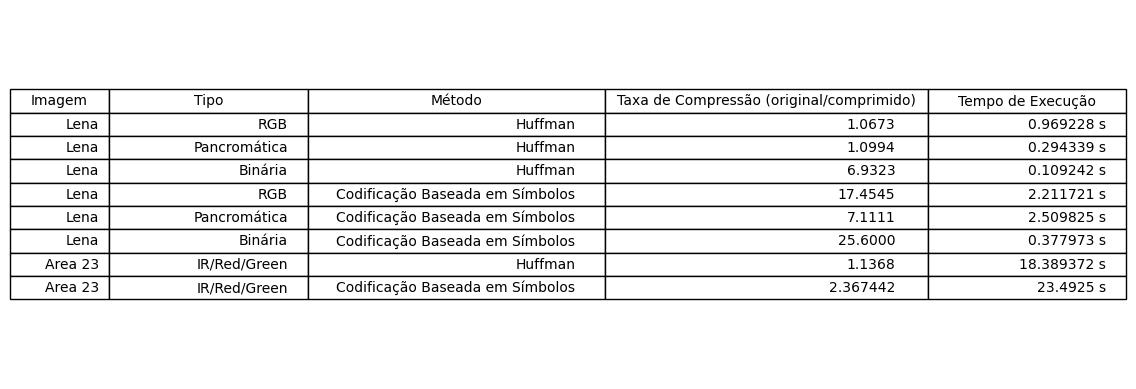

In [46]:
dados = [
    ["Lena", "RGB", "Huffman", "1.0673", "0.969228 s"],
    ["Lena", "Pancromática", "Huffman", "1.0994", "0.294339 s"],
    ["Lena", "Binária", "Huffman", "6.9323", "0.109242 s"],
    ["Lena", "RGB", "Codificação Baseada em Símbolos", "17.4545", "2.211721 s"],
    ["Lena", "Pancromática", "Codificação Baseada em Símbolos", "7.1111", "2.509825 s"],
    ["Lena", "Binária", "Codificação Baseada em Símbolos", "25.6000", "0.377973 s"],
    ["Area 23", "IR/Red/Green", "Huffman", "1.1368", "18.389372 s"],
    ["Area 23", "IR/Red/Green", "Codificação Baseada em Símbolos", "2.367442", "23.4925 s"]
]
colunas = ["Imagem", "Tipo", "Método", "Taxa de Compressão (original/comprimido)", "Tempo de Execução"]

fig, ax = plt.subplots()
ax.axis("off")  # esconde eixos

tabela = ax.table(
    cellText=dados,
    colLabels=colunas,
    loc="center",
    colWidths=[0.20, 0.40, 0.60, 0.65, 0.40]
)

tabela.auto_set_font_size(False)
tabela.set_fontsize(10)
tabela.scale(1, 1.4) 

plt.show()